# 03 — EDA e decisão: quais métricas validam textura?

A pergunta original tem duas partes, e este notebook responde as duas separadamente:

1. **quais métricas nos ajudam a validar** real vs. sintético;
2. **qual é a consistência** entre eles, e se ela é parecida **entre os conjuntos**.

## O critério

Uma métrica só tem direito de opinar sobre o modelo se passa em dois testes prévios:

* **sensibilidade** — separa o real de pelo menos um degradado conhecido
  (`bicubic_2/4` = suavização, `real_noise` = excesso). AUC ≥ 0,80.
* **estabilidade** — **não** separa dois quadrantes disjuntos do mesmo tecido real
  (`real_q1` × `real_q2`). Uma métrica que separa tecido real de si mesmo está
  medindo posição ou ruído, não textura.

Só então o veredito sobre o sintético:

| AUC(real, syn) | AUC(real_lp, syn_lp) | veredito |
|---|---|---|
| alta | ~0,5 | `falha_escala_fina` — o desvio está na escala fina; o tecido é consistente |
| alta | alta | `falha_escala_tecido` — desvio real de textura |
| ~0,5 | ~0,5 | `modelo_passa` nesse eixo |

Fora dessa classificação ficam duas categorias que não respondem a essa pergunta:
`artefato_de_geracao` (detectores do xadrez de 2 px e da blocagem JPEG — são razões
pico/fundo e o passa-baixa não as neutraliza) e as métricas pareadas `*_vs_real`,
degeneradas no próprio real e tratadas à parte.

**Contra o garimpo de resultado:** a lista de métricas foi fixada no `config.yaml`
antes de olhar qualquer resultado, **todas** são reportadas (métrica cega é
resultado, não fracasso), duplicatas exatas da GLCM são removidas antes do FDR, e a
correção de Benjamini-Hochberg acompanha o tamanho de efeito contra o piso.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from texture import stats as tstats  # noqa: E402
from texture.pipeline import CONTROL_SETS  # noqa: E402
from texture.store import Config, metrics_wide  # noqa: E402

cfg = Config(ROOT / "config.yaml")
man = pd.read_csv(cfg.out / "manifest.csv")
mets = pd.read_parquet(cfg.out / "metrics.parquet")
qc = pd.read_parquet(cfg.out / "qc.parquet").pivot_table(index="pair_id", columns="flag", values="value")
wide = metrics_wide(mets)
print(f"{wide.shape[1]} métricas, {len(man)} pares, {man.patient_id.nunique()} pacientes")

191 métricas, 225 pares, 202 pacientes


## 1. Piso de ruído — o que é diferença e o que é medição

Dois quadrantes disjuntos da **mesma** ROI real. A dispersão entre eles é o piso: um
desvio menor que isso é indistinguível do ruído da própria métrica. É o análogo
pareado do "real vs. real", que num desenho pareado não existe.

In [2]:
floor_rows = []
for m in wide.columns:
    q1 = wide.xs("real_q1", level="set")[m] if "real_q1" in wide.index.get_level_values("set") else pd.Series(dtype=float)
    q2 = wide.xs("real_q2", level="set")[m] if "real_q2" in wide.index.get_level_values("set") else pd.Series(dtype=float)
    if q1.dropna().empty or q2.dropna().empty:
        continue
    floor_rows.append({"metric": m, "auc_floor": tstats.auc_mannwhitney(q1, q2),
                       "noise_floor_p95": tstats.noise_floor(q1.to_numpy(), q2.to_numpy())})
floor = pd.DataFrame(floor_rows).set_index("metric")
print(f"{len(floor)} métricas com piso medido; "
      f"{(floor.auc_floor >= 0.8).sum()} separam tecido real de si mesmo (instáveis)")
print(floor.sort_values("auc_floor", ascending=False).head(8).round(3).to_string())

183 métricas com piso medido; 0 separam tecido real de si mesmo (instáveis)
                        auc_floor  noise_floor_p95
metric                                            
r2_fit                      0.556            0.060
lacunarity_4px              0.542            0.573
lacunarity_8px              0.538            0.561
lacunarity_16px             0.531            0.542
nyquist_excess              0.531            0.817
band_frac_0.125_0.25        0.526            0.101
band_frac_0.0625_0.125      0.525            0.059
band_frac_0.25_0.5          0.525            0.102


## 2. A tabela de decisão

Uma linha por métrica, ordenada por sensibilidade aos controles. O topo é a resposta
a "quais métricas nos ajudam a validar textura".

In [3]:
table = tstats.decision_table(wide, man, CONTROL_SETS, cfg["stats"])
table.to_csv(cfg.out / "decision_table.csv", index=False)
print(table["verdict"].value_counts().to_string())

12 métricas duplicadas removidas antes da correção de FDR (ex.: glcm_ASM_d2_a135 == glcm_ASM_d1_a135)


/Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties
/Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties
/Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties


verdict
cega                   82
falha_escala_tecido    42
falha_escala_fina      19
inconclusiva           18
modelo_passa            8
artefato_de_geracao     4


In [4]:
cols = ["metric", "max_auc_control", "auc_floor", "auc_syn", "auc_syn_lp",
        "auc_syn_vs_noise", "bias_vs_floor", "disp_ratio", "p_value_bh", "verdict"]
useful = table[table.verdict.isin(["falha_escala_fina", "falha_escala_tecido", "modelo_passa"])]
print(f"MÉTRICAS ÚTEIS ({len(useful)} de {len(table)})\n")
print(useful[cols].head(25).round(3).to_string(index=False))

MÉTRICAS ÚTEIS (69 de 173)

                       metric  max_auc_control  auc_floor  auc_syn  auc_syn_lp  auc_syn_vs_noise  bias_vs_floor  disp_ratio  p_value_bh             verdict
           band_frac_0.25_0.5            1.000      0.525    0.824       0.800             0.700          0.166       2.680       0.000   falha_escala_fina
     lbp_P8R1_nonuniform_frac            1.000      0.504    0.554       0.636             1.000          0.099       0.378       0.159        modelo_passa
    lbp_P16R2_nonuniform_frac            1.000      0.504    0.594       0.716             1.000          0.228       0.392       0.000        modelo_passa
            lbp_P16R2_entropy            1.000      0.507    0.581       0.747             1.000          0.202       0.566       0.000        modelo_passa
                  grad_median            1.000      0.500    0.904       0.891             0.534          1.856       3.416       0.000 falha_escala_tecido
    glcm_dissimilarity_d1_a90       

### Por que a coluna é `bias_vs_floor` e não o p-valor

Com 225 pares pareados, **quase toda** métrica atinge significância: o teste
responde "o desvio é exatamente zero?", e a resposta é sempre não. A pergunta útil
é outra — *o desvio é maior do que a própria métrica flutua entre dois pedaços do
mesmo tecido real?* `bias_vs_floor` é essa razão. Abaixo de 1, o desvio está dentro
do ruído de medição, por menor que seja o p.

In [5]:
print(f"métricas com p (BH) < 0,05: {(table.p_value_bh < 0.05).sum()} de {len(table)}"
      f"  <- significância não discrimina aqui")
print(f"métricas com desvio acima do piso (bias_vs_floor > 1): "
      f"{(table.bias_vs_floor > 1).sum()}")

métricas com p (BH) < 0,05: 167 de 173  <- significância não discrimina aqui
métricas com desvio acima do piso (bias_vs_floor > 1): 51


### Detectores de artefato — categoria própria

`nyquist_excess`, `harmonic_*px` e `band_frac_corners` medem **artefato de geração**,
não textura. Sua versão passa-baixa não neutraliza nada, porque são razões pico/fundo
e o filtro atenua numerador e denominador juntos — o veredito por banda não se aplica.

In [6]:
art = table[table.verdict == "artefato_de_geracao"]
print(art[["metric", "auc_syn", "auc_syn_lp", "bias_vs_floor", "disp_ratio"]].round(3).to_string(index=False))

           metric  auc_syn  auc_syn_lp  bias_vs_floor  disp_ratio
     harmonic_4px    0.614       0.554          0.211       0.308
   nyquist_excess    1.000       0.972          2.467       0.536
band_frac_corners    0.590       0.548          0.035       0.482
     harmonic_8px    0.606       0.619          0.169       0.249


In [7]:
blind = table[table.verdict == "cega"]
print(f"\nMÉTRICAS CEGAS ({len(blind)}) — reportadas porque métrica cega é resultado, não fracasso\n")
print(blind[["metric", "max_auc_control", "auc_syn"]].head(15).round(3).to_string(index=False))
unstable = table[table.verdict == "instavel"]
if len(unstable):
    print(f"\nMÉTRICAS INSTÁVEIS ({len(unstable)}) — separam dois pedaços do mesmo tecido real\n")
    print(unstable[["metric", "auc_floor", "auc_syn"]].head(10).round(3).to_string(index=False))


MÉTRICAS CEGAS (82) — reportadas porque métrica cega é resultado, não fracasso

                     metric  max_auc_control  auc_syn
             glcm_ASM_d1_a0            0.797    0.604
          glcm_energy_d1_a0            0.797    0.604
glcm_correlation_d1_angmean            0.795    0.639
   glcm_correlation_d1_a135            0.790    0.647
    glcm_correlation_d1_a45            0.785    0.649
            glcm_ASM_d1_a90            0.782    0.649
         glcm_energy_d1_a90            0.782    0.649
           tophat_area_frac            0.779    0.587
     glcm_entropy_d4_angstd            0.776    0.616
        glcm_ASM_d1_angmean            0.774    0.639
     glcm_energy_d1_angmean            0.774    0.639
glcm_correlation_d2_angmean            0.768    0.644
            glcm_ASM_d2_a90            0.763    0.657
         glcm_energy_d2_a90            0.763    0.657
           glcm_ASM_d1_a135            0.762    0.650


## 3. O mapa da decisão

Cada ponto é uma métrica. Eixo x: quanto ela separa real de sintético na banda
completa. Eixo y: o mesmo depois de remover a escala fina. Pontos **na diagonal**
apontam desvio de textura de tecido; pontos que **caem para a base** apontam desvio
concentrado no artefato de 2 px.

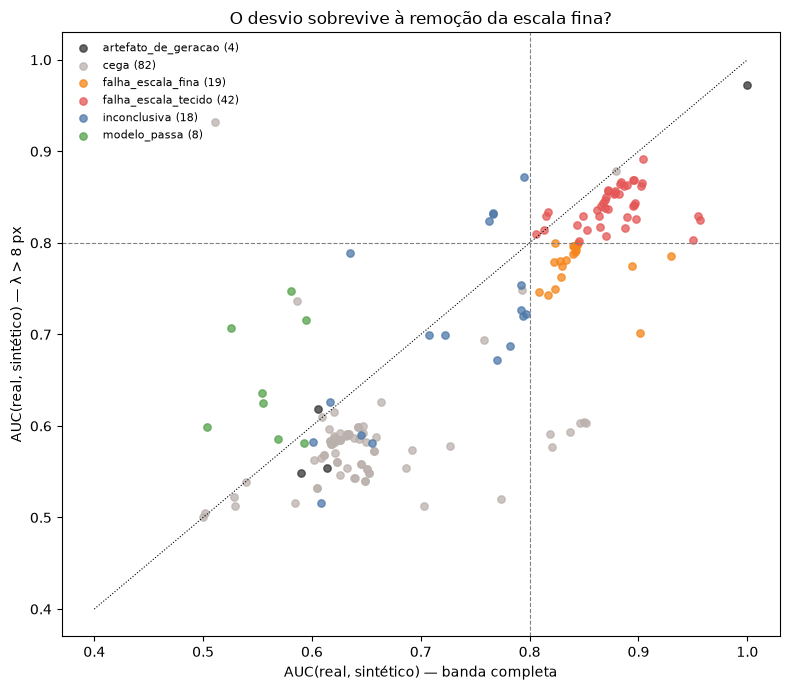

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = {"falha_escala_tecido": "#E45756", "falha_escala_fina": "#F58518",
          "modelo_passa": "#54A24B", "cega": "#BAB0AC", "instavel": "#B279A2",
          "inconclusiva": "#4C78A8"}
for verd, grp in table.groupby("verdict"):
    ax.scatter(grp.auc_syn, grp.auc_syn_lp, s=28, alpha=0.75, label=f"{verd} ({len(grp)})",
               color=colors.get(verd, "#333"))
ax.plot([0.4, 1], [0.4, 1], color="k", lw=0.8, ls=":")
ax.axhline(0.8, color="grey", lw=0.8, ls="--"); ax.axvline(0.8, color="grey", lw=0.8, ls="--")
ax.set(xlabel="AUC(real, sintético) — banda completa",
       ylabel="AUC(real, sintético) — λ > 8 px",
       title="O desvio sobrevive à remoção da escala fina?")
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

## 3b. Estrutura ou só quantidade de ruído?

`real_noise` foi calibrado para ter **a mesma potência de alta frequência** que o
sintético (razão espectral 2,48 vs 2,47 em λ = 4 px). Então uma métrica que separa
`syn` de `real_noise` não está vendo *quanto* de alta frequência existe — está
vendo a **estrutura**: o ruído é branco, o desvio do modelo é periódico e
espacialmente organizado. É a coluna que distingue "o modelo adiciona energia" de
"o modelo adiciona um padrão".

In [9]:
struct = table[table.verdict != "cega"].nlargest(15, "auc_syn_vs_noise")
print(struct[["metric", "auc_syn", "auc_syn_vs_noise", "verdict"]].round(3).to_string(index=False))

                      metric  auc_syn  auc_syn_vs_noise             verdict
              nyquist_excess    1.000             1.000 artefato_de_geracao
    lbp_P8R1_nonuniform_frac    0.554             1.000        modelo_passa
            lbp_P8R1_entropy    0.770             1.000        inconclusiva
   lbp_P16R2_nonuniform_frac    0.594             1.000        modelo_passa
          lbp_P8R1_flat_frac    0.655             1.000        inconclusiva
           lbp_P16R2_entropy    0.581             1.000        modelo_passa
      glcm_entropy_d1_angstd    0.930             0.999   falha_escala_fina
       glcm_energy_d1_angstd    0.792             0.999        inconclusiva
           band_frac_corners    0.590             0.998 artefato_de_geracao
  glcm_homogeneity_d1_angstd    0.955             0.996 falha_escala_tecido
          glcm_ASM_d1_angstd    0.616             0.995        inconclusiva
glcm_dissimilarity_d1_angstd    0.957             0.995 falha_escala_tecido
       glcm_

## 4. Viés e dispersão são perguntas diferentes

Um modelo pode acertar a mediana e colapsar a diversidade. `disp_ratio` < 1 é
colapso; > 1 é dispersão excessiva. O teste de viés não vê nenhum dos dois.

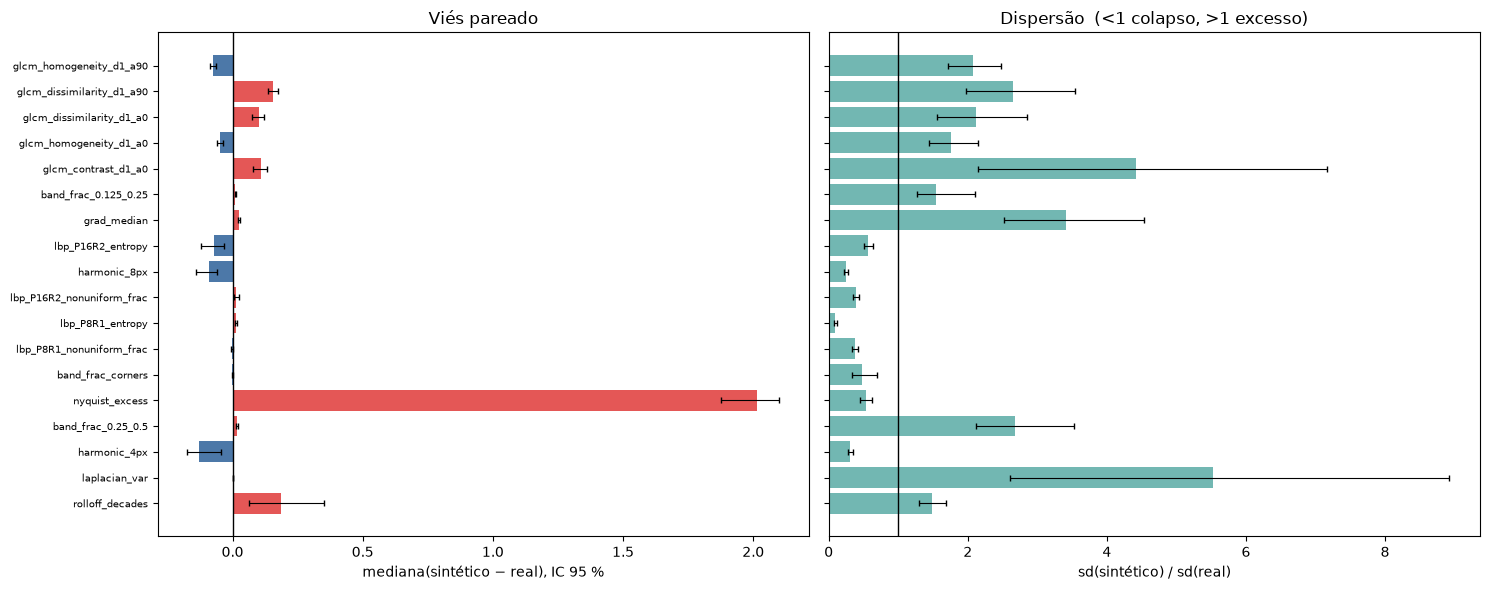

In [10]:
top = table[table.verdict != "cega"].nlargest(18, "max_auc_control")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
y = np.arange(len(top))
ax1.barh(y, top.bias_median, color=["#E45756" if b > 0 else "#4C78A8" for b in top.bias_median])
ax1.errorbar(top.bias_median, y, xerr=[top.bias_median - top.bias_lo, top.bias_hi - top.bias_median],
             fmt="none", ecolor="k", elinewidth=0.8, capsize=2)
ax1.set(yticks=y, yticklabels=top.metric, xlabel="mediana(sintético − real), IC 95 %",
        title="Viés pareado")
ax1.axvline(0, color="k", lw=1); ax1.tick_params(axis="y", labelsize=7)
ax2.barh(y, top.disp_ratio, color="#72B7B2")
ax2.errorbar(top.disp_ratio, y, xerr=[top.disp_ratio - top.disp_lo, top.disp_hi - top.disp_ratio],
             fmt="none", ecolor="k", elinewidth=0.8, capsize=2)
ax2.axvline(1, color="k", lw=1)
ax2.set(xlabel="sd(sintético) / sd(real)", title="Dispersão  (<1 colapso, >1 excesso)")
fig.tight_layout()

## 5. A consistência é parecida entre os conjuntos?

Kruskal-Wallis dos deltas pareados (sintético − real) entre estratos, com BH. Um p
pequeno significa que o desvio do modelo **depende do estrato** — e que um número
agregado sobre os 225 pares esconde essa diferença.

In [11]:
het_cols = [f"p_heterogeneity_{s}_bh" for s in cfg["stats"]["strata"]]
het = table[table.verdict != "cega"][["metric"] + het_cols].copy()
alpha = float(cfg["stats"]["fdr_alpha"])
print("métricas úteis com heterogeneidade significativa (BH < %.2f):" % alpha)
for c in het_cols:
    strat = c.replace("p_heterogeneity_", "").replace("_bh", "")
    n = (het[c] < alpha).sum()
    print(f"  {strat:12s}: {n} de {len(het)}")
print()
print(het.nsmallest(12, het_cols[0]).round(4).to_string(index=False))

métricas úteis com heterogeneidade significativa (BH < 0.05):
  batch       : 10 de 91
  abnormality : 2 de 91
  split       : 0 de 91

                      metric  p_heterogeneity_batch_bh  p_heterogeneity_abnormality_bh  p_heterogeneity_split_bh
                harmonic_8px                    0.0244                          0.3671                    0.9982
      glcm_entropy_d1_angstd                    0.0244                          0.2863                    0.9982
             rolloff_decades                    0.0312                          0.5987                    0.9982
                harmonic_4px                    0.0312                          0.3529                    0.9982
              nyquist_excess                    0.0312                          0.0569                    0.9982
glcm_dissimilarity_d1_angstd                    0.0312                          0.1243                    0.9982
            lbp_P8R1_entropy                    0.0320                   

## 6. Sensibilidade: as ROIs flagadas mudam a conclusão?

~25 % das ROIs reais têm blocagem JPEG (CBIS-DDSM distribuído comprimido) e algumas
têm padding de borda. Nenhuma foi excluída. Se a tabela de decisão muda ao removê-las,
a conclusão depende de artefato do **conjunto real** e isso precisa constar.

In [12]:
flagged = qc.index[(qc["harmonic_8px_real"] > 1.5) | (qc["zero_frac_real"] > 0.01)]
clean_pairs = man[~man.pair_id.isin(flagged)]
print(f"{len(flagged)} ROIs flagadas; {len(clean_pairs)} pares limpos")
wide_clean = wide[wide.index.get_level_values("pair_id").isin(clean_pairs.pair_id)]
table_clean = tstats.decision_table(wide_clean, clean_pairs, CONTROL_SETS, cfg["stats"])
cmp = (table.set_index("metric")[["auc_syn", "auc_syn_lp", "verdict"]]
       .join(table_clean.set_index("metric")[["auc_syn", "auc_syn_lp", "verdict"]],
             lsuffix="_todos", rsuffix="_limpos"))
changed = cmp[cmp.verdict_todos != cmp.verdict_limpos]
print(f"\n{len(changed)} métricas mudam de veredito ao excluir as ROIs flagadas:")
print(changed.round(3).head(15).to_string() if len(changed) else "  nenhuma — a conclusão é robusta")

74 ROIs flagadas; 151 pares limpos


12 métricas duplicadas removidas antes da correção de FDR (ex.: glcm_ASM_d2_a135 == glcm_ASM_d1_a135)


/Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties
/Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties
/Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties



20 métricas mudam de veredito ao excluir as ROIs flagadas:
                          auc_syn_todos  auc_syn_lp_todos        verdict_todos  auc_syn_limpos  auc_syn_lp_limpos       verdict_limpos
metric                                                                                                                                
rolloff_decades                   0.608             0.515         inconclusiva           0.514              0.542         modelo_passa
band_frac_0.25_0.5                0.824             0.800    falha_escala_fina           0.784              0.760         inconclusiva
lbp_P8R1_nonuniform_frac          0.554             0.636         modelo_passa           0.737              0.567         inconclusiva
glcm_homogeneity_d2_a0            0.817             0.833  falha_escala_tecido           0.774              0.839         inconclusiva
glcm_dissimilarity_d2_a0          0.815             0.829  falha_escala_tecido           0.771              0.834         inconclu

## 7. Resumo executivo

In [13]:
print(f"""
RESUMO
------
Métricas avaliadas          : {len(table)}
  úteis (sensíveis+estáveis): {len(useful)}
  cegas                     : {len(blind)}
  instáveis                 : {len(unstable)}

Vereditos sobre o modelo:
{table.verdict.value_counts().to_string()}

Arquivos gerados em {cfg.out}:
  decision_table.csv, metrics.parquet, profiles.parquet, qc.parquet, manifest.csv
  sidecar_*.json (parâmetros, config_hash, git HEAD, versões)

Ressalvas que acompanham qualquer uso destes números:
  * pixel spacing desconhecido -> tudo em ciclos/pixel; beta NAO comparavel com
    literatura em mm^-1;
  * o controle bicubico usa fator k INFERIDO (o gerador nao salvou a baixa
    resolucao) - ele demonstra sensibilidade das metricas, nao reproduz a entrada
    real do modelo;
  * ~25% das ROIs reais tem blocagem JPEG (CBIS-DDSM comprimido);
  * SSIM/PSNR sao referencia de fidelidade estrutural, nao evidencia de textura.
""")


RESUMO
------
Métricas avaliadas          : 173
  úteis (sensíveis+estáveis): 69
  cegas                     : 82
  instáveis                 : 0

Vereditos sobre o modelo:
verdict
cega                   82
falha_escala_tecido    42
falha_escala_fina      19
inconclusiva           18
modelo_passa            8
artefato_de_geracao     4

Arquivos gerados em /Users/bringel/ARIA/UPenn/avaliacao-de-mamografias-sinteticas/outputs/gen-fid:
  decision_table.csv, metrics.parquet, profiles.parquet, qc.parquet, manifest.csv
  sidecar_*.json (parâmetros, config_hash, git HEAD, versões)

Ressalvas que acompanham qualquer uso destes números:
  * pixel spacing desconhecido -> tudo em ciclos/pixel; beta NAO comparavel com
    literatura em mm^-1;
  * o controle bicubico usa fator k INFERIDO (o gerador nao salvou a baixa
    resolucao) - ele demonstra sensibilidade das metricas, nao reproduz a entrada
    real do modelo;
  * ~25% das ROIs reais tem blocagem JPEG (CBIS-DDSM comprimido);
  * SSIM/PSNR s